# Nasdaq 종목정보 조회
- https://www.nasdaq.com/market-activity/stocks/screener

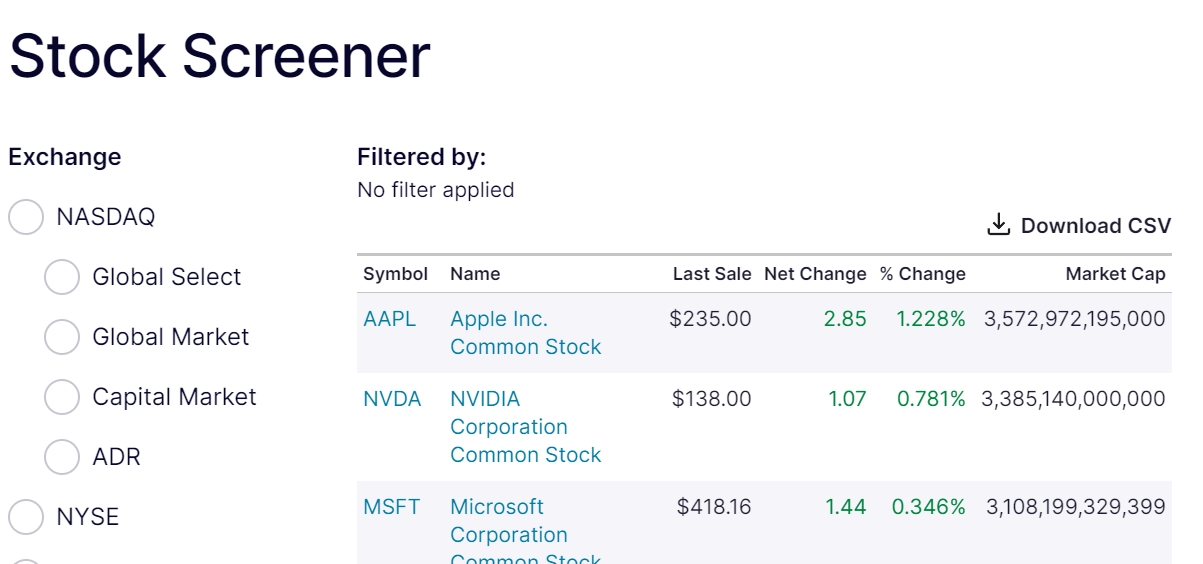

In [12]:
import pandas as pd

nasdaq_df = pd.read_csv("./data/nasdaq_screener_202604.csv", na_filter=False)

In [13]:
nasdaq_df.head()

,Symbol,Name,Last Sale,Net Change,% Change,Market Cap,Country,IPO Year,Volume,Sector,Industry
0,A,Agilent Technologies Inc. Common Stock,$116.92,3.040,2.669%,33041862904.00,United States,1999,1384565,Industrials,Biotechnology: Laboratory Analytical Instruments
1,AA,Alcoa Corporation Common Stock,$71.76,-1.200,-1.645%,18934772426.00,United States,2016,7131647,Industrials,Aluminum
2,AACB,Artius II Acquisition Inc. Class A Ordinary Sh...,$10.36,0.000,0.00%,0.00,United States,2025,106,,
3,AACBR,Artius II Acquisition Inc. Rights,$0.2776,0.000,0.00%,0.00,United States,2025,20,,
4,AACG,ATA Creativity Global American Depositary Shares,$1.01,0.025,2.538%,43460297.00,China,2008,11938,Real Estate,Other Consumer Services


In [14]:
len(nasdaq_df)

7082

In [29]:
nasdaq_f_df = nasdaq_df[nasdaq_df['Symbol'].str.contains(r'[^a-zA-Z0-9-_/^ ]', regex=True)]

In [30]:
nasdaq_f_df

,Symbol,Name,Last Sale,Net Change,% Change,Market Cap,Country,IPO Year,Volume,Sector,Industry,id


In [ ]:
# 전처리
# nasdaq_f_df = nasdaq_df[nasdaq_df['Symbol'].str.contains(r'[^a-zA-X0-9-_/^ ]', regex=True)]
nasdaq_df['id'] = nasdaq_df['Symbol'].str.strip().replace(r'[/^]', '_', regex=True)
nasdaq_dict = nasdaq_df.to_dict(orient='records')

In [34]:
different_rows = nasdaq_df[nasdaq_df['id'] != nasdaq_df['Symbol']]
different_rows[['id', 'Symbol', 'Name']]

,id,Symbol,Name
35,ABR_D,ABR^D,Arbor Realty Trust 6.375% Series D Cumulative ...
36,ABR_E,ABR^E,Arbor Realty Trust 6.25% Series E Cumulative R...
37,ABR_F,ABR^F,Arbor Realty Trust 6.25% Series F Fixed-to-Flo...
83,ACP_A,ACP^A,abrdn Income Credit Strategies Fund 5.250% Ser...
85,ACR_C,ACR^C,ACRES Commercial Realty Corp. 8.625% Fixed-to-...
...,...,...,...
6880,WRB_G,WRB^G,W.R. Berkley Corporation 4.25% Subordinated De...
6881,WRB_H,WRB^H,W.R. Berkley Corporation 4.125% Subordinated D...
6896,WSO_B,WSO/B,Watsco Inc.
6975,XRN_A,XRN^A,Chiron Real Estate Inc. Series A Cumulative Re...


In [16]:
nasdaq_df

,Symbol,Name,Last Sale,Net Change,% Change,Market Cap,Country,IPO Year,Volume,Sector,Industry,id
0,A,Agilent Technologies Inc. Common Stock,$116.92,3.0400,2.669%,33041862904.00,United States,1999,1384565,Industrials,Biotechnology: Laboratory Analytical Instruments,A
1,AA,Alcoa Corporation Common Stock,$71.76,-1.2000,-1.645%,18934772426.00,United States,2016,7131647,Industrials,Aluminum,AA
2,AACB,Artius II Acquisition Inc. Class A Ordinary Sh...,$10.36,0.0000,0.00%,0.00,United States,2025,106,,,AACB
3,AACBR,Artius II Acquisition Inc. Rights,$0.2776,0.0000,0.00%,0.00,United States,2025,20,,,AACBR
4,AACG,ATA Creativity Global American Depositary Shares,$1.01,0.0250,2.538%,43460297.00,China,2008,11938,Real Estate,Other Consumer Services,AACG
...,...,...,...,...,...,...,...,...,...,...,...,...
7077,ZVIA,Zevia PBC Class A Common Stock,$1.18,0.0300,2.609%,88619728.00,United States,2021,382591,Consumer Staples,Beverages (Production/Distribution),ZVIA
7078,ZVRA,Zevra Therapeutics Inc. Common Stock,$9.59,-0.0900,-0.93%,563044091.00,United States,,568188,Health Care,Biotechnology: Pharmaceutical Preparations,ZVRA
7079,ZWS,Zurn Elkay Water Solutions Corporation Common ...,$47.61,2.2100,4.868%,7976689093.00,United States,2012,1009288,Industrials,Industrial Machinery/Components,ZWS
7080,ZYBT,Zhengye Biotechnology Holding Limited Class A ...,$0.9555,0.0385,4.198%,45282460.00,China,2025,29682,Health Care,Biotechnology: Pharmaceutical Preparations,ZYBT


## 인덱스를 생성하고 준비한 종목코드 데이터를 추가

In [35]:
from dotenv import load_dotenv
import os

load_dotenv()
MEILISEARCH_MASTER_KEY = os.environ['MEILISEARCH_MASTER_KEY']

from meilisearch import Client
client = Client("http://127.0.0.1:7700", MEILISEARCH_MASTER_KEY)

In [ ]:
client.index('nasdaq').delete()

In [ ]:
client.index('nasdaq').add_documents(nasdaq_dict, primary_key='id')

# 인덱스에서 검색

In [ ]:
client.index('nasdaq').search('apple')
# client.index('nasdaq').search('사과')
# client.index('nasdaq').search('ms')

In [40]:
import yfinance as yf
stock = yf.Ticker('AAPL')
hist = stock.history(period="5y")
print(hist)

                                 Open        High         Low       Close  \
Date                                                                        
2021-04-09 00:00:00-04:00  126.424615  129.580350  126.103194  129.541397   
2021-04-12 00:00:00-04:00  129.073923  129.395343  127.233071  127.827209   
2021-04-13 00:00:00-04:00  128.995963  131.158234  128.499215  130.934204   
2021-04-14 00:00:00-04:00  131.430965  131.489402  128.236260  128.596634   
2021-04-15 00:00:00-04:00  130.340116  131.489424  130.164789  131.002426   
...                               ...         ...         ...         ...   
2026-04-01 00:00:00-04:00  254.080002  256.179993  253.330002  255.630005   
2026-04-02 00:00:00-04:00  254.199997  256.130005  250.649994  255.919998   
2026-04-06 00:00:00-04:00  256.510010  262.160004  256.459991  258.859985   
2026-04-07 00:00:00-04:00  256.160004  256.200012  245.699997  253.500000   
2026-04-08 00:00:00-04:00         NaN         NaN         NaN         NaN   